In [1]:
import torch.nn as nn

Epoch 1:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.2692 | Val Loss: 0.1895 | F1: 0.9332


Epoch 2:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.1084 | Val Loss: 0.1107 | F1: 0.9609


Epoch 3:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 0.0817 | Val Loss: 0.1084 | F1: 0.9617


Epoch 4:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 4 | Train Loss: 0.0703 | Val Loss: 0.1145 | F1: 0.9590


Epoch 5:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 5 | Train Loss: 0.0627 | Val Loss: 0.0703 | F1: 0.9763

--- BASELINE CNN REPORT ---
              precision    recall  f1-score   support

      NORMAL       0.96      0.53      0.68       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.81       624
   macro avg       0.87      0.76      0.77       624
weighted avg       0.85      0.81      0.80       624



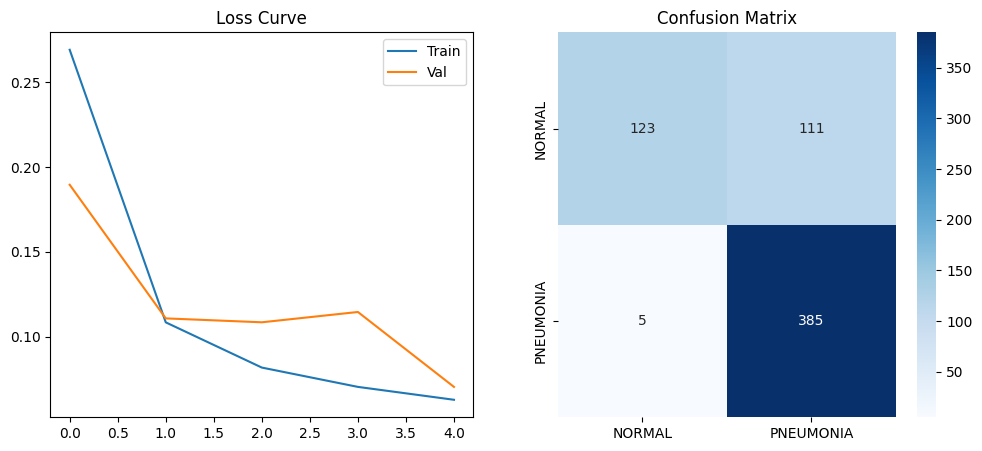

In [2]:
import os, random, cv2, torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A

from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# --- CONFIG ---
SEED, IMG_SIZE, BATCH_SIZE, NUM_EPOCHS = 42, 224, 32, 5
LR, WEIGHT_DECAY = 1e-4, 1e-4

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- DATA PATH ---
DATASET_ROOT = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray")

def build_df(split):
    records = []
    for cls in CLASS_NAMES:
        for img in (DATASET_ROOT / split / cls).glob("*"):
            records.append({"label": CLASS_TO_IDX[cls], "path": str(img)})
    return pd.DataFrame(records)

train_val_df = pd.concat([build_df("train"), build_df("val")])
test_df = build_df("test")

train_df, valid_df = train_test_split(train_val_df, test_size=0.15,
                                      stratify=train_val_df["label"], random_state=SEED)

# --- CLASS BALANCING ---
class_counts = train_df["label"].value_counts().sort_index()
class_weights = len(train_df) / (2 * class_counts)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

sample_weights = train_df["label"].map(class_weights.to_dict()).values
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# --- AUGMENTATION ---
train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

class ChestDataset(Dataset):
    def __init__(self, df, tfms):
        self.df = df.reset_index(drop=True)
        self.tfms = tfms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.path, cv2.IMREAD_GRAYSCALE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = self.tfms(image=img)["image"]
        return img, int(row.label)

train_loader = DataLoader(ChestDataset(train_df, train_tfms),
                          batch_size=BATCH_SIZE, sampler=sampler)

val_loader = DataLoader(ChestDataset(valid_df, val_tfms),
                        batch_size=BATCH_SIZE, shuffle=False)

test_loader = DataLoader(ChestDataset(test_df, val_tfms),
                         batch_size=BATCH_SIZE, shuffle=False)

# --- MODEL: SIMPLE CNN ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)

# --- TRAIN SETUP ---
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = AdamW(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = defaultdict(list)

# --- VALIDATION ---
def validate():
    model.eval()
    loss_total = 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)

            loss_total += loss.item()*x.size(0)
            preds = torch.argmax(out,1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    f1 = f1_score(all_labels, all_preds)
    return loss_total/len(val_loader.dataset), f1

# --- TRAIN LOOP ---
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0

    for x,y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()*x.size(0)

    scheduler.step()

    val_loss, val_f1 = validate()

    print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader.dataset):.4f} | Val Loss: {val_loss:.4f} | F1: {val_f1:.4f}")

    history["train_loss"].append(train_loss/len(train_loader.dataset))
    history["val_loss"].append(val_loss)

# --- TEST ---
model.eval()
labels_all, preds_all = [], []

with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        out = model(x)
        preds = torch.argmax(out,1)

        labels_all.extend(y.numpy())
        preds_all.extend(preds.cpu().numpy())

print("\n--- BASELINE CNN REPORT ---")
print(classification_report(labels_all, preds_all, target_names=CLASS_NAMES))

# --- PLOTS ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(labels_all, preds_all),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.title("Confusion Matrix")
plt.show()